# WAVE — Exploratory Data Analysis

**Project:** WAVE — Water-process Anomaly and Variance Explorer  
**Dataset:** SWaT (Secure Water Treatment) — iTrust, SUTD Singapore  
**Author:** Ildebrando  

---

## Objectives
This EDA is oriented toward **supervised learning** (Step 1 of the project).  
Labels are available and used here to guide feature understanding and preprocessing decisions.

1. Load and clean the merged dataset
2. Assess data quality (duplicates, missing values, sampling frequency)
3. Understand class balance (Normal vs Attack)
4. Visualize attack episodes on time-series
5. Profile sensor distributions by class — where do normal and attack differ?
6. Analyse per-sensor discriminative power (mean shift, point-biserial correlation)
7. Actuator state analysis by class (MV + binary)
8. Correlation analysis — normal vs attack
9. Summarise findings and define preprocessing checklist for notebook 02

---

## SWaT Process Overview

SWaT is a scaled-down water treatment plant with 6 sub-processes:

| Stage | Description | Key sensors |
|-------|-------------|-------------|
| P1 | Raw water storage + dosing | FIT101, LIT101, MV101, P101 |
| P2 | Chemical dosing (NaCl, NaOCl, HCl) | AIT201, AIT202, AIT203 |
| P3 | Ultrafiltration | FIT301, LIT301, DPIT301 |
| P4 | De-chlorination (UV) | AIT401, AIT402 |
| P5 | Reverse osmosis | AIT501-503, FIT501-504 |
| P6 | Permeate backwash | FIT601, P601 |

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('.')
from src.features.engineering import identify_sensor_types

# Paths
DATA_RAW       = Path('data/raw')
DATA_PROCESSED = Path('data/processed')
FIGURES        = Path('reports/figures')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
FIGSIZE    = (16, 5)
CLR_NORMAL = 'steelblue'
CLR_ATTACK = 'coral'

print('Setup complete')

Setup complete


## 1. Load & Clean Data

In [3]:
# ---- Load merged CSV ----
df = pd.read_csv(DATA_RAW / 'merged.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded: 1,441,719 rows x 53 columns


In [4]:
# ---- Strip spaces from column names ----
df.columns = df.columns.str.strip()
print('Columns:', df.columns.tolist())

Columns: ['Timestamp', 'FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Normal/Attack']


In [5]:
# ---- Quick inspection ----
df.head(3)

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,2.427057,522.8467,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,28/12/2015 10:00:01 AM,2.446274,522.8860,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,28/12/2015 10:00:02 AM,2.489191,522.8467,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal


In [6]:
df.tail(3)

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
1441716,2/1/2016 1:41:09 PM,2.502322,524.2206,2.0,2,1,168.899,8.633236,304.5373,2.461026,...,2,1,249.5193,0.945119,187.5801,0.0,1,1,1,Attack
1441717,2/1/2016 1:41:10 PM,2.482465,524.2991,2.0,2,1,168.899,8.634518,304.5373,2.461026,...,2,1,249.5193,0.945119,187.5801,0.0,1,1,1,Attack
1441718,2/1/2016 1:41:11 PM,2.469654,524.2206,2.0,2,1,168.899,8.635479,304.5373,2.461026,...,2,1,249.5193,0.945119,187.5801,0.0,1,1,1,Attack


In [7]:
# ---- Drop duplicates (before setting index — Timestamp still a column) ----
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f'Dropped {n_before - len(df):,} duplicate rows — {len(df):,} remaining')

Dropped 494,991 duplicate rows — 946,728 remaining


In [9]:
# ---- Parse timestamp and set index ----
TIMESTAMP_COL = 'Timestamp'
LABEL_COL     = 'Normal/Attack'

df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], format='mixed', dayfirst=True)
df.set_index(TIMESTAMP_COL, inplace=True)
df.sort_index(inplace=True)

print(f'Time range:     {df.index.min()} to {df.index.max()}')
print(f'Total duration: {df.index.max() - df.index.min()}')

Time range:     2015-12-22 16:00:00 to 2016-01-02 14:59:59
Total duration: 10 days 22:59:59


In [10]:
# ---- Extract label and features ----
y = (df[LABEL_COL].str.strip() == 'Attack').astype(int)
FEATURE_COLS = [c for c in df.columns if c != LABEL_COL]
X = df[FEATURE_COLS].copy()

print(f'Features: {len(FEATURE_COLS)}')
print(f'Rows:     {len(X):,}')

Features: 51
Rows:     946,728


In [11]:
# ---- Identify sensor types ----
continuous_cols, mv_cols, binary_cols = identify_sensor_types(X)

print(f'Continuous sensors:  {len(continuous_cols)}')
print(f'Ordinal valves (MV): {len(mv_cols)}')
print(f'Binary actuators:    {len(binary_cols)}')
print(f'MV cols:     {mv_cols}')
print(f'Binary cols: {binary_cols}')

Continuous sensors:  25
Ordinal valves (MV): 6
Binary actuators:    20
MV cols:     ['MV101', 'MV201', 'MV301', 'MV302', 'MV303', 'MV304']
Binary cols: ['P101', 'P102', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'P301', 'P302', 'P401', 'P402', 'P403', 'P404', 'UV401', 'P501', 'P502', 'P601', 'P602', 'P603']


In [12]:
# ---- Missing values ----
missing = X.isnull().sum()
print(f'Total missing values: {missing.sum()}')
if missing.sum() > 0:
    print(missing[missing > 0])

Total missing values: 3477663
MV101     496809
AIT201    496809
MV201     496809
P201      496809
P202      496809
P204      496809
MV303     496809
dtype: int64


In [13]:
# ---- Sampling frequency check ----
time_diffs = pd.Series(X.index).diff().dropna()
print('Sampling interval:')
print(time_diffs.describe())
# Expected: 1 second

Sampling interval:
count                       946727
mean     0 days 00:00:01.000076051
std      0 days 00:00:00.083304862
min                0 days 00:00:00
25%                0 days 00:00:01
50%                0 days 00:00:01
75%                0 days 00:00:01
max                0 days 00:01:22
Name: Timestamp, dtype: object


## 2. Class Balance

Class distribution:
  Normal: 892,107 rows (94.23%)
  Attack: 54,621 rows (5.77%)


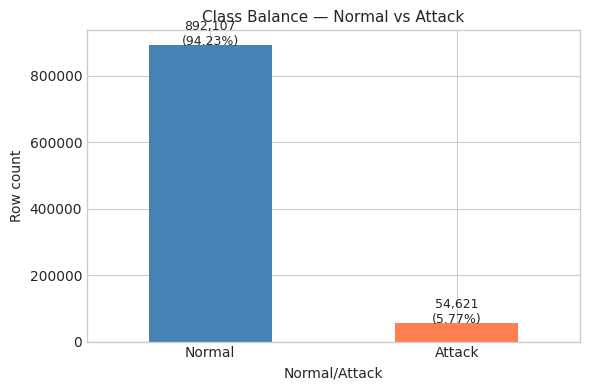


Imbalance ratio (Normal:Attack) = 16.3:1
=> Consider: class_weight="balanced", SMOTE, or threshold tuning in modeling


In [14]:
# ---- Class counts and percentages ----
class_counts = y.value_counts().rename({0: 'Normal', 1: 'Attack'})
class_pct    = (class_counts / len(y) * 100).round(2)

print('Class distribution:')
for cls in ['Normal', 'Attack']:
    print(f'  {cls}: {class_counts[cls]:,} rows ({class_pct[cls]}%)')

# ---- Bar chart ----
fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind='bar', ax=ax,
                  color=[CLR_NORMAL, CLR_ATTACK], edgecolor='none', width=0.5)
ax.set_title('Class Balance — Normal vs Attack', fontsize=11)
ax.set_ylabel('Row count')
ax.set_xticklabels(['Normal', 'Attack'], rotation=0)
for i, v in enumerate(class_counts):
    ax.text(i, v + 500, f'{v:,}\n({class_pct.iloc[i]}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = class_counts['Normal'] / class_counts['Attack']
print(f'\nImbalance ratio (Normal:Attack) = {imbalance_ratio:.1f}:1')
print('=> Consider: class_weight="balanced", SMOTE, or threshold tuning in modeling')

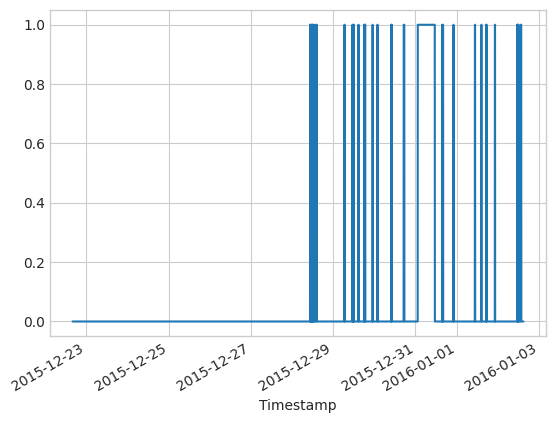

In [16]:
y.plot();

Attack episodes: 35
Duration  min: 100s  |  max: 35899s  |  median: 443s


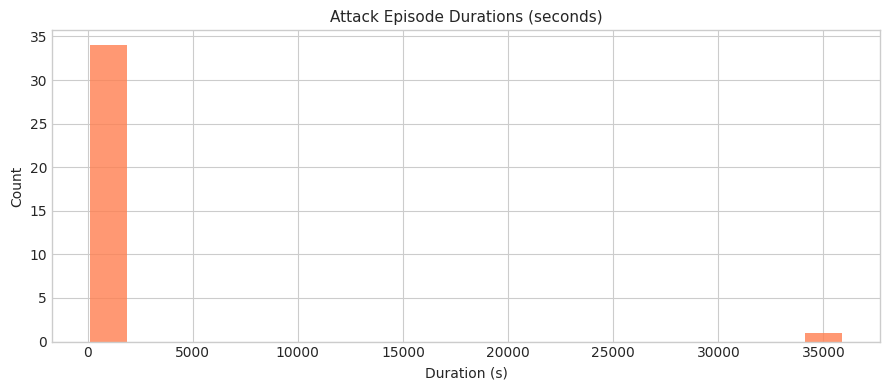

In [15]:
# ---- Attack episodes: count and duration ----
# Group consecutive rows with the same label into episodes
# This is robust to timestamp gaps and avoids diff() misalignment
episodes = (
    y.reset_index()
     .assign(episode_id=(y.values != np.roll(y.values, 1)).cumsum())
     .groupby('episode_id')
     .agg(label=(LABEL_COL if LABEL_COL in y.name else y.name, 'first'),
          start=('Timestamp', 'first'),
          end=('Timestamp', 'last'),
          n_rows=('Timestamp', 'count'))
)

# Rename columns robustly regardless of y.name
y_df = y.rename('label').reset_index()
y_df['episode_id'] = (y_df['label'].values != np.roll(y_df['label'].values, 1)).cumsum()
episodes = (
    y_df.groupby('episode_id')
        .agg(label=('label', 'first'),
             start=('Timestamp', 'first'),
             end=('Timestamp', 'last'),
             n_rows=('Timestamp', 'count'))
)
episodes['duration_s'] = (episodes['end'] - episodes['start']).dt.total_seconds()
attack_episodes = episodes[episodes['label'] == 1]
n_episodes = len(attack_episodes)
durations  = attack_episodes['duration_s'].values

print(f'Attack episodes: {n_episodes}')
print(f'Duration  min: {durations.min():.0f}s  |  max: {durations.max():.0f}s  |  median: {np.median(durations):.0f}s')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(durations, bins=20, color=CLR_ATTACK, edgecolor='none', alpha=0.8)
ax.set_title('Attack Episode Durations (seconds)', fontsize=11)
ax.set_xlabel('Duration (s)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES / 'attack_episode_durations.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Time-Series with Attack Windows

In [19]:
# ---- Helper: shade attack periods on an axis ----
# Uses pre-computed attack_episodes df for consistency with episode count cell
def shade_attacks(ax, attack_eps):
    for _, row in attack_eps.iterrows():
        ax.axvspan(row['start'], row['end'],
                   alpha=0.25, color=CLR_ATTACK)

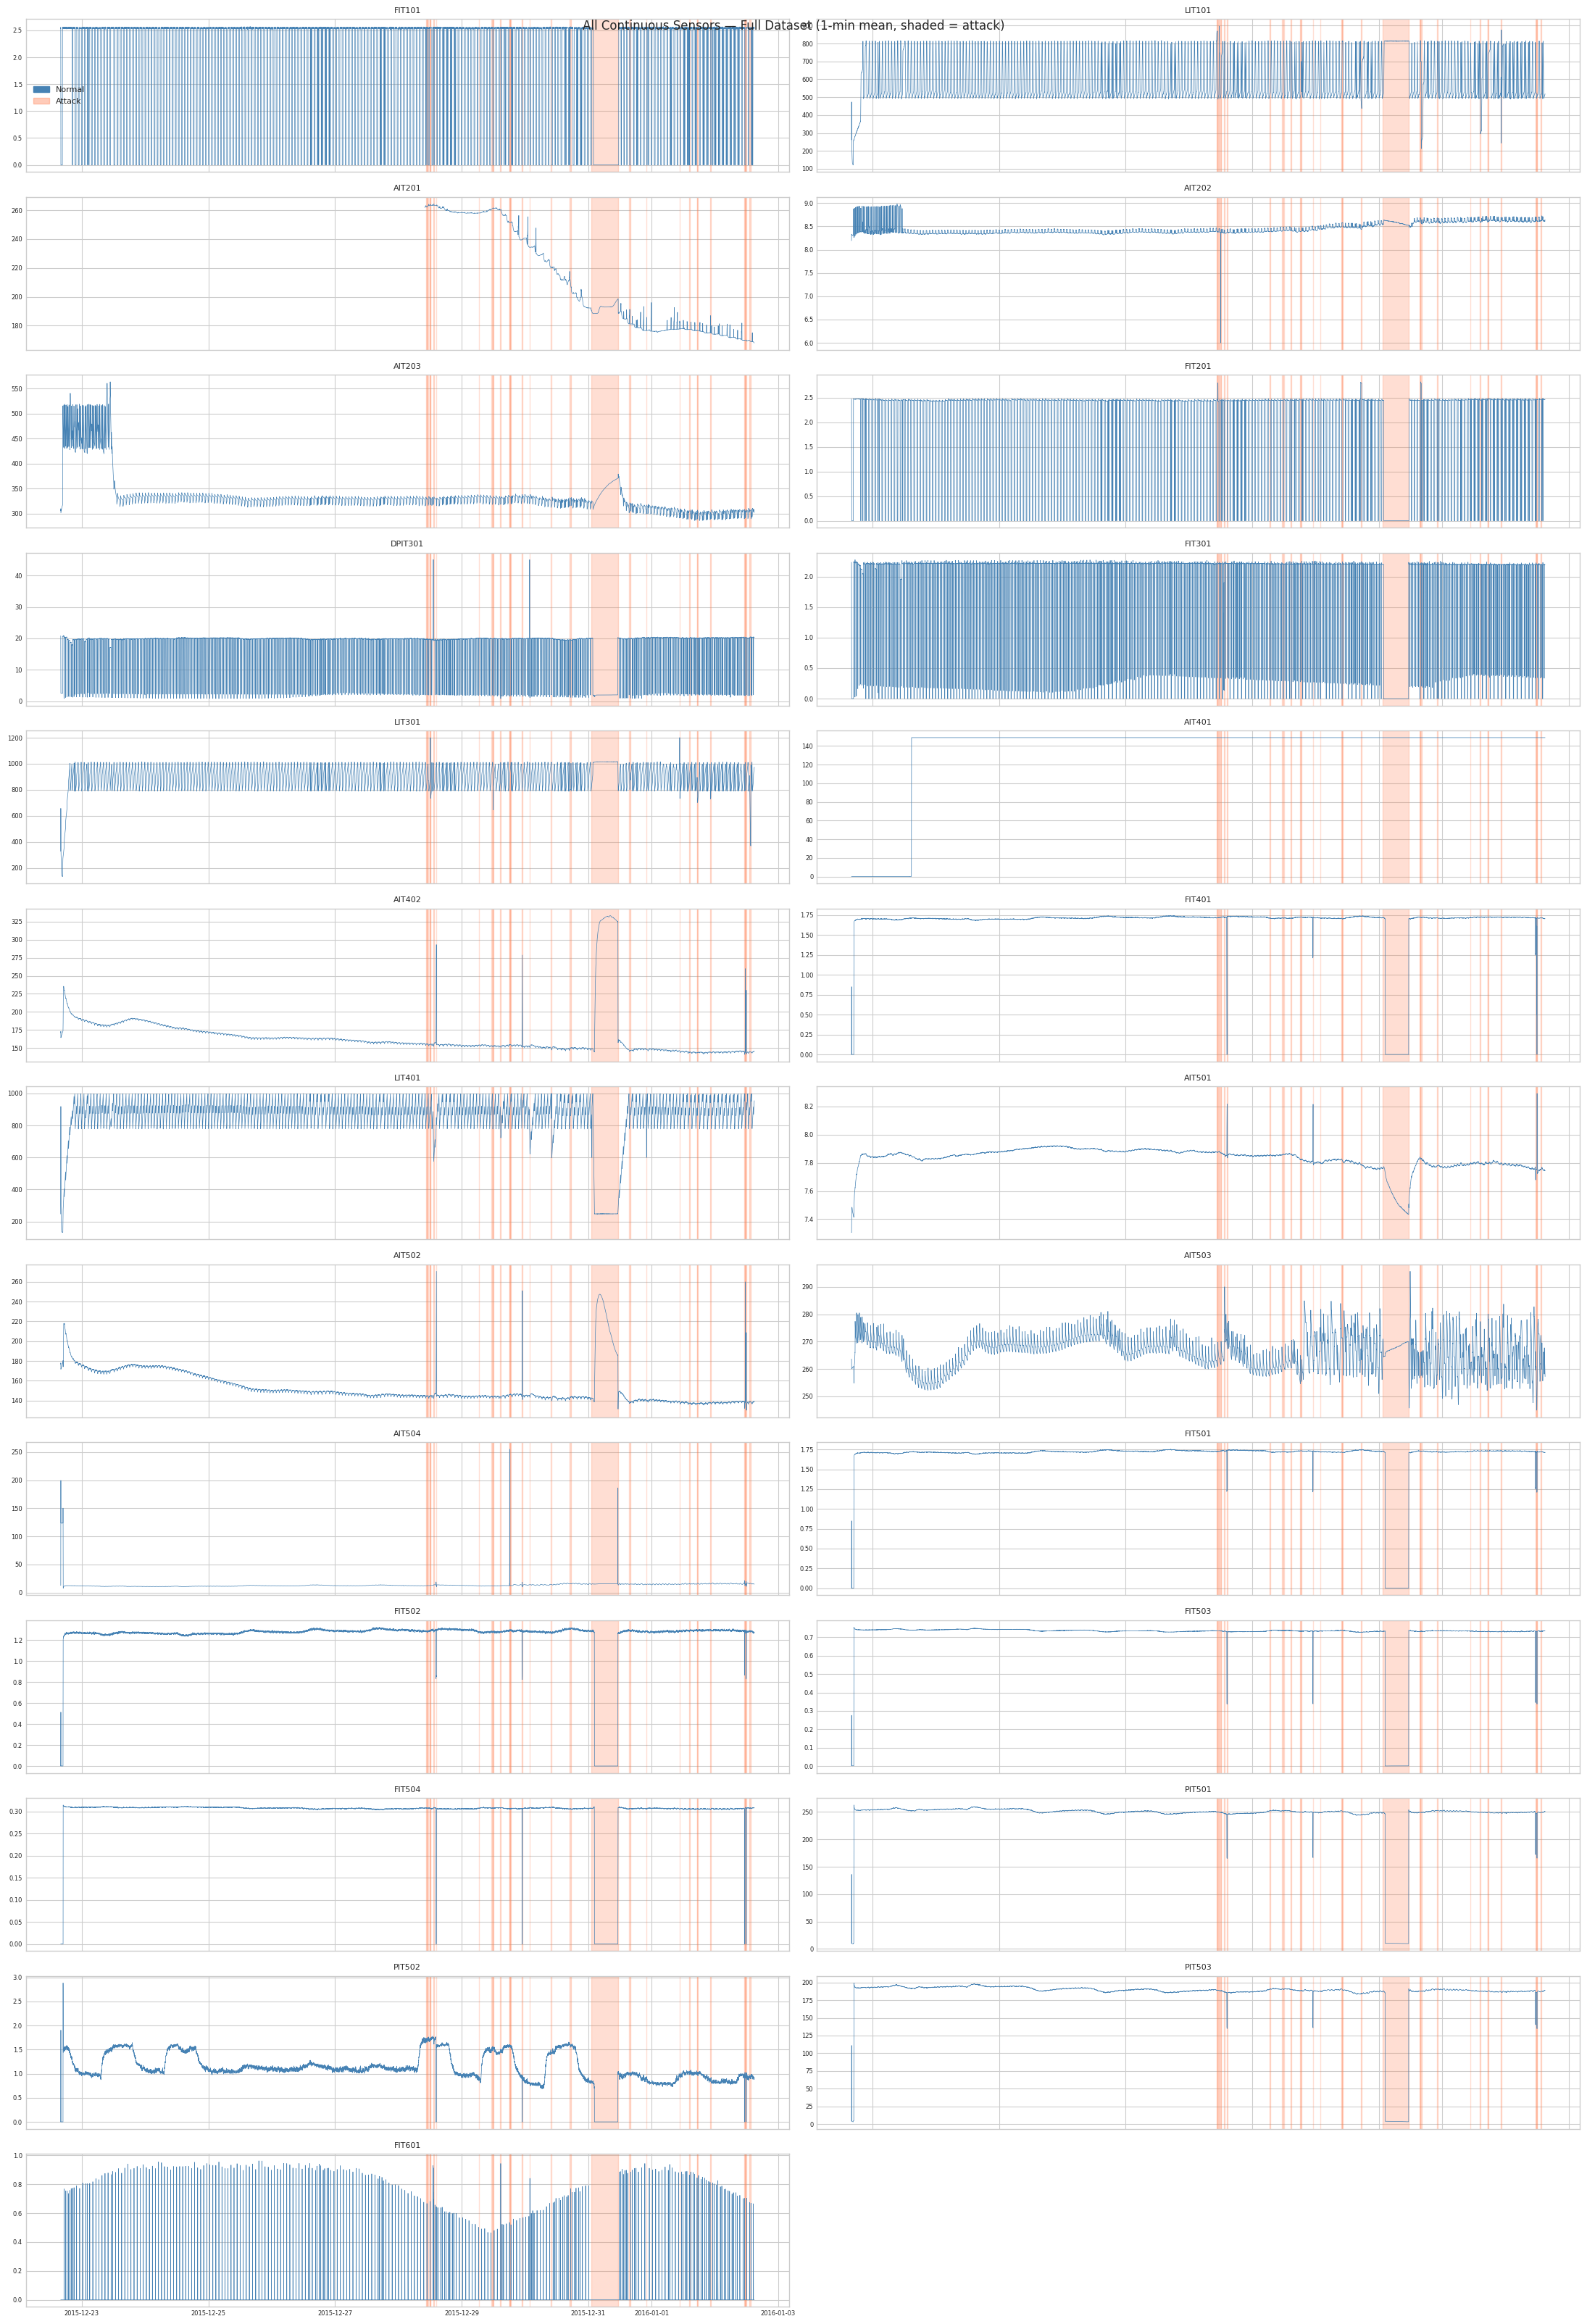

In [22]:
# ---- Time-series — all continuous sensors ----
# Resample to 1-min to keep plotting fast (~10k points per sensor)
X_1min = X[continuous_cols].resample('1min').mean()

n_cols = 2
n_rows = int(np.ceil(len(continuous_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 2.5), sharex=True)
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, continuous_cols)):
    ax.plot(X_1min.index, X_1min[col], lw=0.5, color=CLR_NORMAL)
    shade_attacks(ax, attack_episodes)
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(handles=[
    mpatches.Patch(color=CLR_NORMAL, label='Normal'),
    mpatches.Patch(color=CLR_ATTACK, alpha=0.4, label='Attack')
], fontsize=8)

plt.suptitle('All Continuous Sensors — Full Dataset (1-min mean, shaded = attack)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'timeseries_all_sensors.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Per-Sensor Discriminative Power

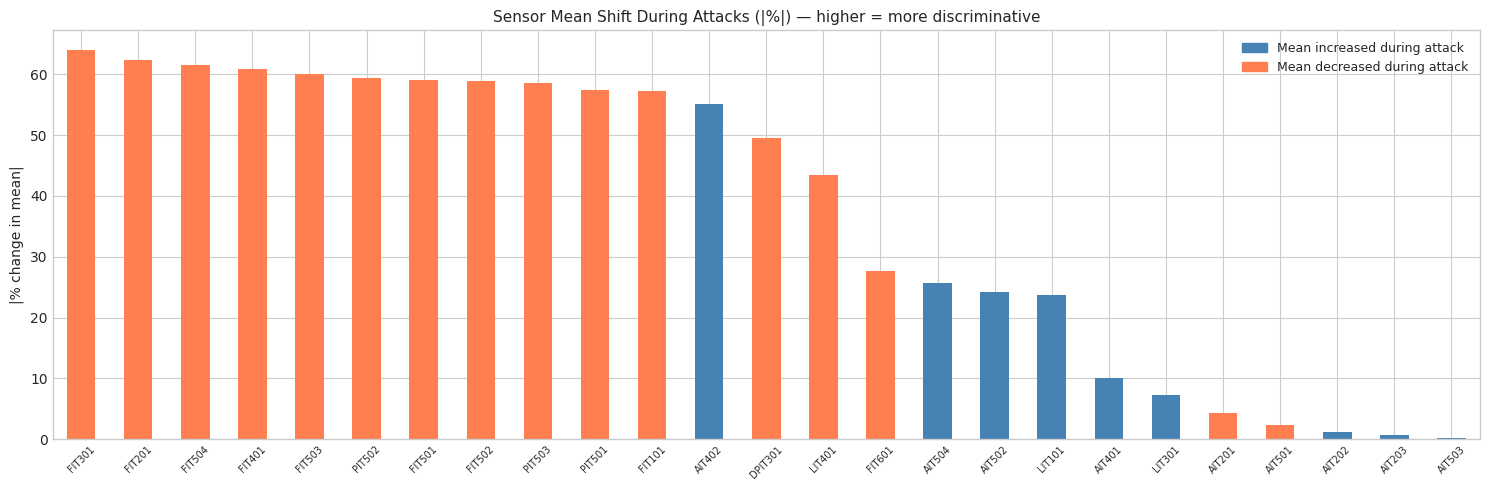

Top 10 most discriminative sensors:
FIT301    64.0
FIT201    62.4
FIT504    61.5
FIT401    60.9
FIT503    60.1
PIT502    59.4
FIT501    59.1
FIT502    59.0
PIT503    58.5
PIT501    57.4


In [24]:
# ---- Mean shift per sensor ----
normal_means = X[continuous_cols][y == 0].mean()
attack_means = X[continuous_cols][y == 1].mean()
mean_shift   = ((attack_means - normal_means) / (normal_means.abs() + 1e-6) * 100)
mean_shift_sorted = mean_shift.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(15, 5))
bar_colors = [CLR_ATTACK if mean_shift[c] < 0 else CLR_NORMAL
              for c in mean_shift_sorted.index]
mean_shift_sorted.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='none')
ax.set_title('Sensor Mean Shift During Attacks (|%|) — higher = more discriminative', fontsize=11)
ax.set_ylabel('|% change in mean|')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.legend(handles=[
    mpatches.Patch(color=CLR_NORMAL, label='Mean increased during attack'),
    mpatches.Patch(color=CLR_ATTACK, label='Mean decreased during attack'),
], fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'sensor_mean_shift.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most discriminative sensors:')
print(mean_shift_sorted.head(10).round(1).to_string())

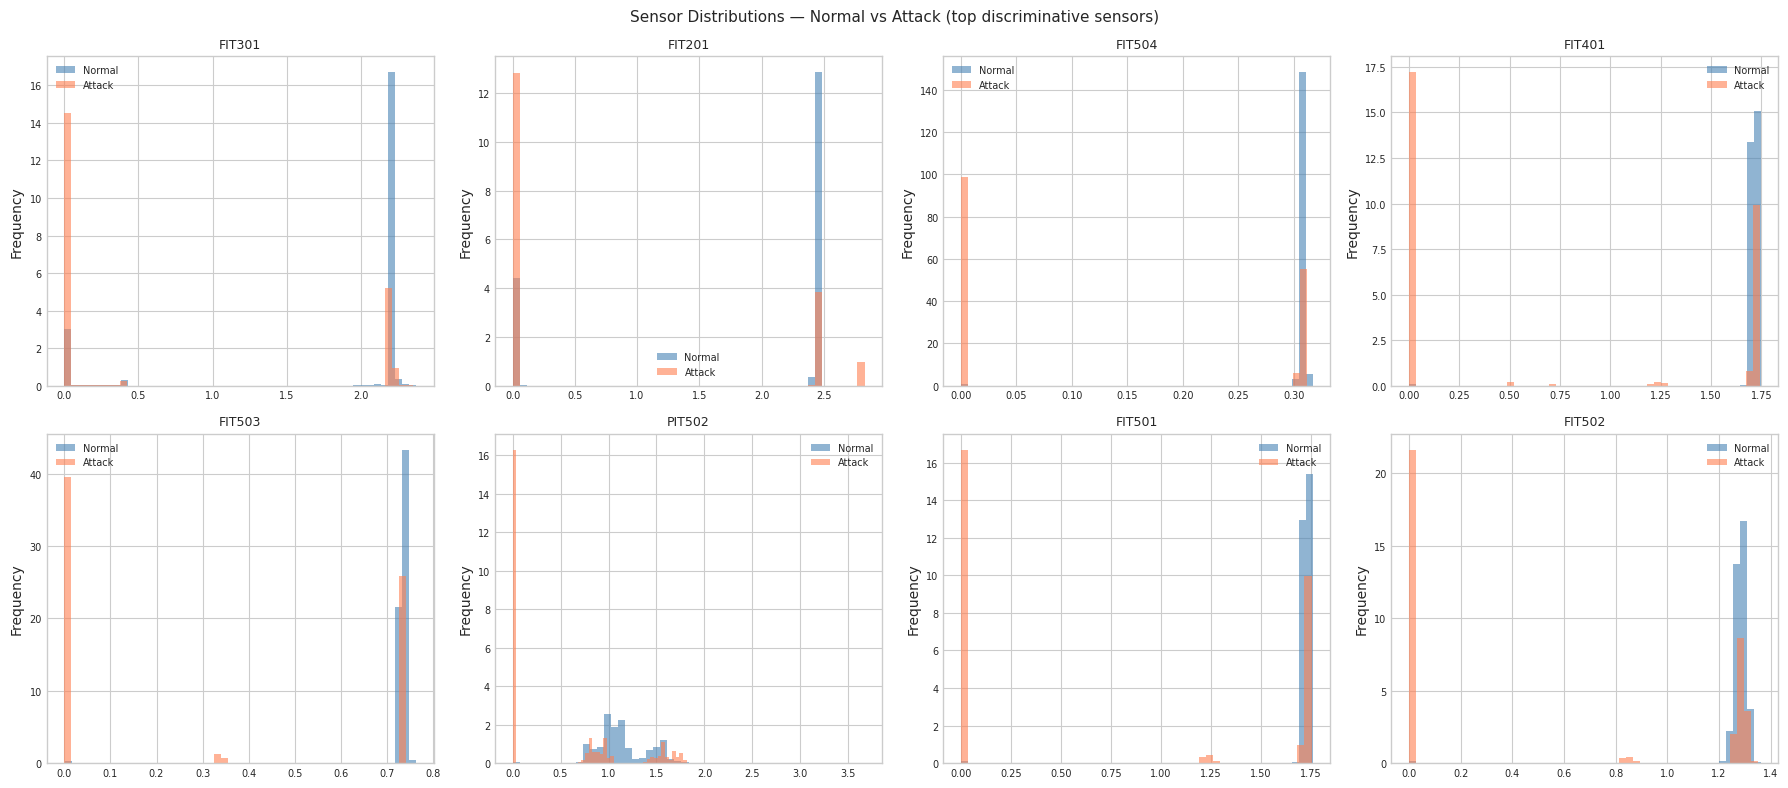

In [25]:
# ---- Distribution overlap: Normal vs Attack — top 8 sensors ----
top_sensors = mean_shift_sorted.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    ax = axes[i]
    X[sensor][y == 0].plot.hist(ax=ax, bins=50, alpha=0.6,
                                color=CLR_NORMAL, density=True, label='Normal')
    X[sensor][y == 1].plot.hist(ax=ax, bins=50, alpha=0.6,
                                color=CLR_ATTACK, density=True, label='Attack')
    ax.set_title(sensor, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle('Sensor Distributions — Normal vs Attack (top discriminative sensors)', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'distributions_normal_vs_attack.png', dpi=150, bbox_inches='tight')
plt.show()

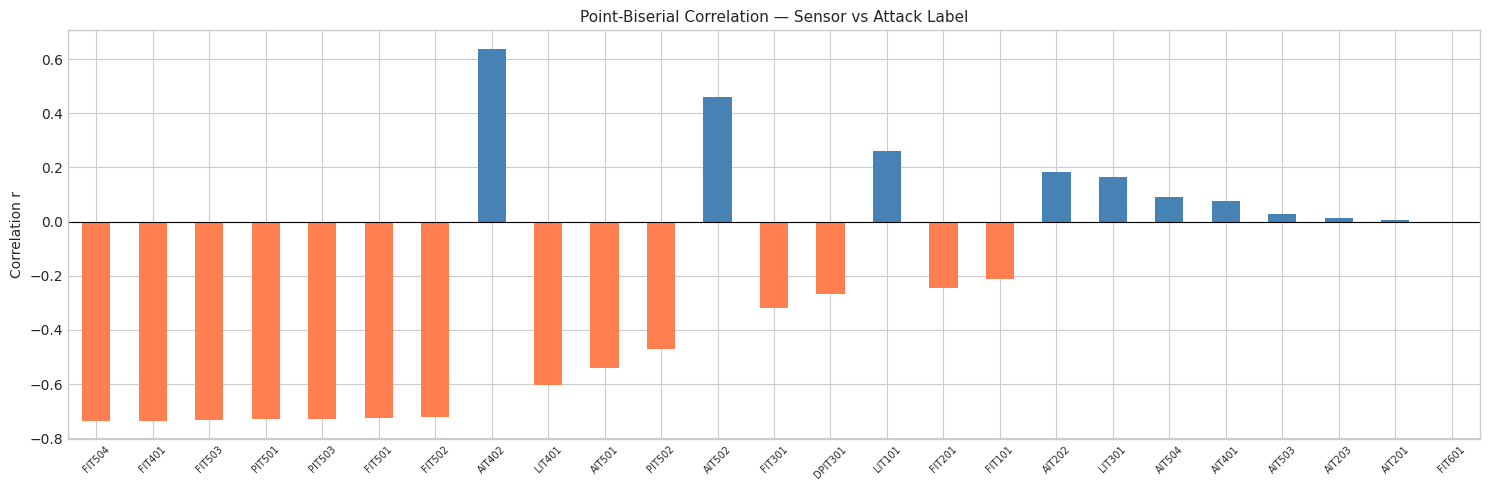

Top 10 sensors most correlated with attack label:
             r    p
FIT504 -0.7349  0.0
FIT401 -0.7348  0.0
FIT503 -0.7328  0.0
PIT501 -0.7299  0.0
PIT503 -0.7292  0.0
FIT501 -0.7244  0.0
FIT502 -0.7206  0.0
AIT402  0.6377  0.0
LIT401 -0.6027  0.0
AIT501 -0.5398  0.0


In [26]:
# ---- Point-biserial correlation: each sensor vs attack label ----
pb_corr = {}
for col in continuous_cols:
    r, p = stats.pointbiserialr(y, X[col].fillna(X[col].median()))
    pb_corr[col] = {'r': r, 'p': p, 'abs_r': abs(r)}

pb_df = pd.DataFrame(pb_corr).T.sort_values('abs_r', ascending=False)

fig, ax = plt.subplots(figsize=(15, 5))
bar_colors = [CLR_ATTACK if r < 0 else CLR_NORMAL for r in pb_df['r']]
pb_df['r'].plot(kind='bar', ax=ax, color=bar_colors, edgecolor='none')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Point-Biserial Correlation — Sensor vs Attack Label', fontsize=11)
ax.set_ylabel('Correlation r')
ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.tight_layout()
plt.savefig(FIGURES / 'pointbiserial_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 sensors most correlated with attack label:')
print(pb_df.head(10)[['r', 'p']].round(4).to_string())

## 5. Actuator State Analysis

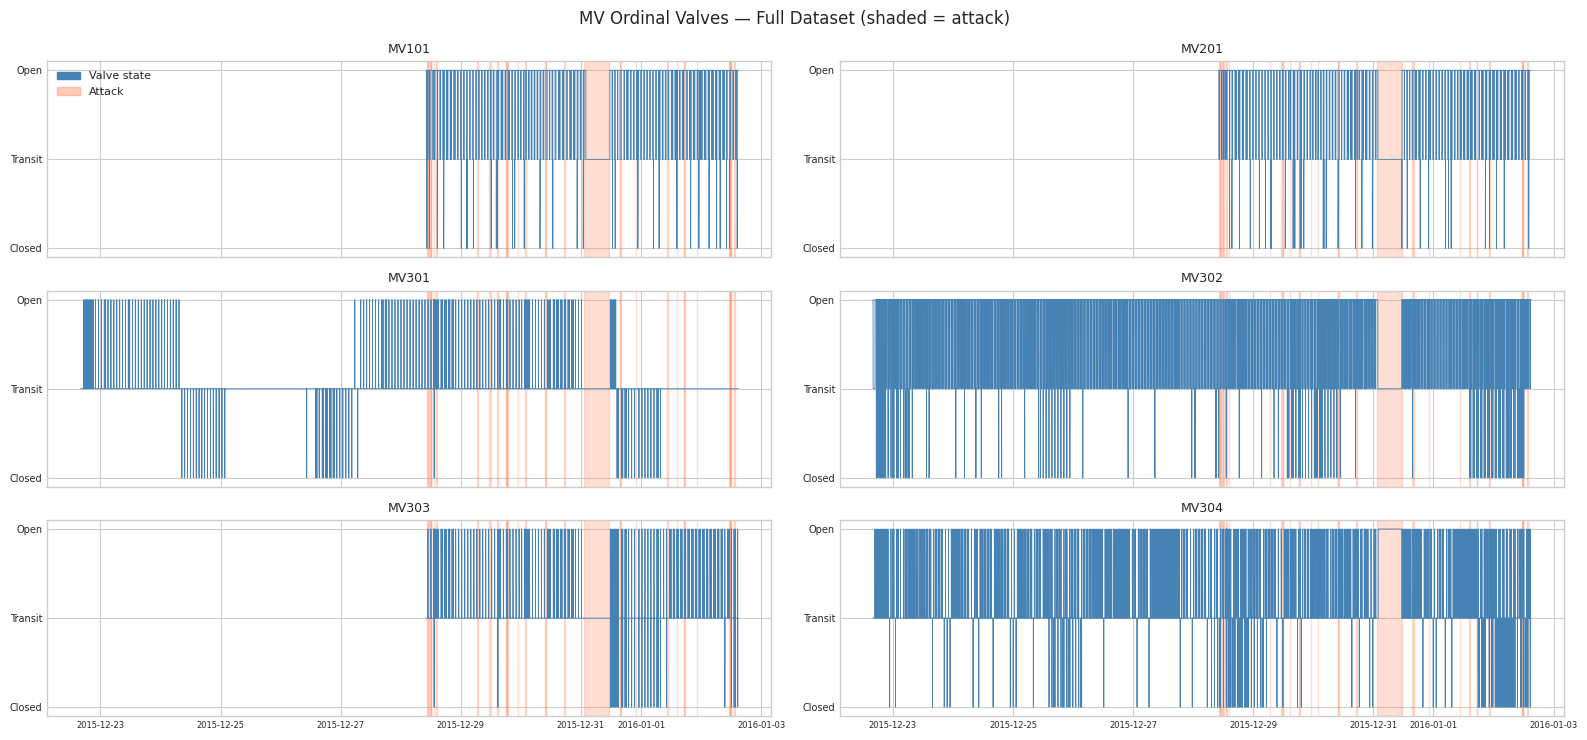

In [29]:
# ---- Time-series — MV ordinal valves ----
# Downsample every 60s to preserve discrete steps
X_mv_ds = X[mv_cols].iloc[::60]

n_cols = 2
n_rows = int(np.ceil(len(mv_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2.5), sharex=True)
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, mv_cols)):
    ax.plot(X_mv_ds.index, X_mv_ds[col], lw=0.6, color=CLR_NORMAL, drawstyle='steps-post')
    shade_attacks(ax, attack_episodes)
    ax.set_title(col, fontsize=9)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Closed', 'Transit', 'Open'], fontsize=7)
    ax.tick_params(axis='x', labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(handles=[
    mpatches.Patch(color=CLR_NORMAL, label='Valve state'),
    mpatches.Patch(color=CLR_ATTACK, alpha=0.4, label='Attack'),
], fontsize=8)

plt.suptitle('MV Ordinal Valves — Full Dataset (shaded = attack)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'timeseries_mv_valves.png', dpi=150, bbox_inches='tight')
plt.show()

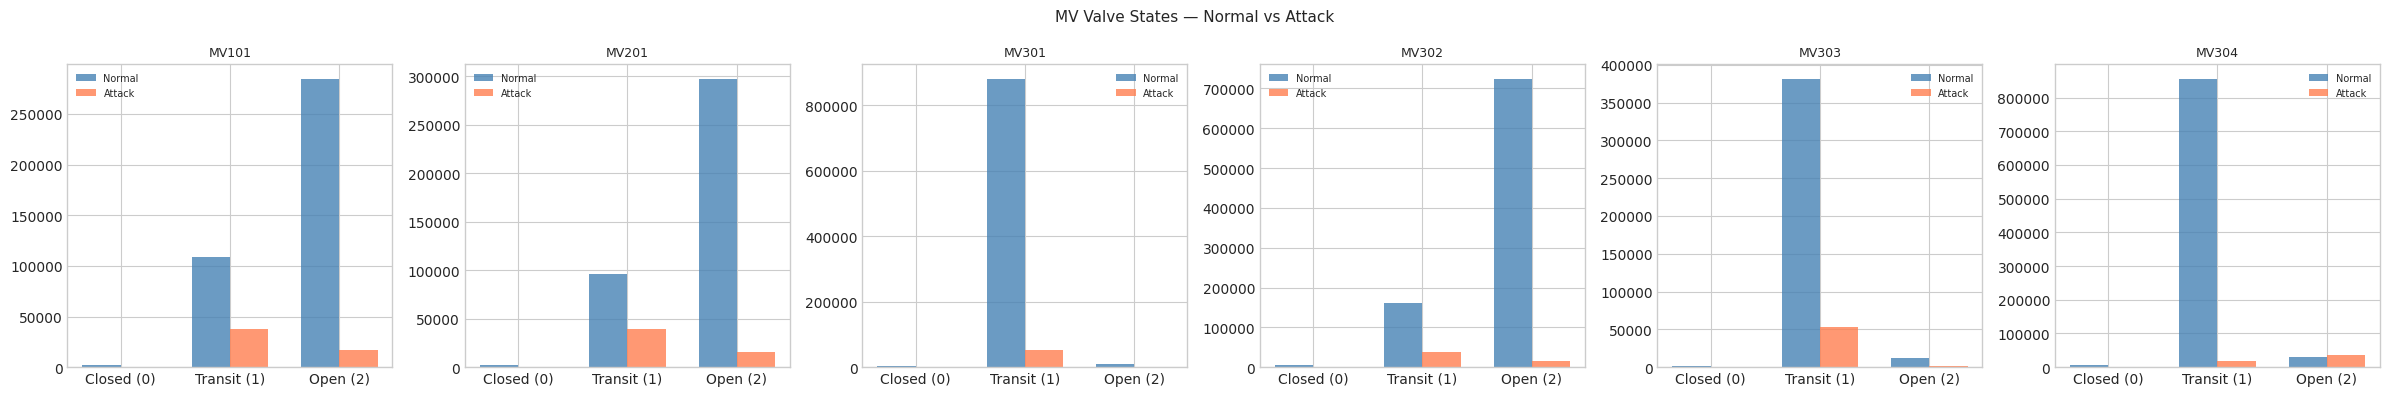

In [30]:
# ---- MV valve state distribution by class ----
if mv_cols:
    fig, axes = plt.subplots(1, len(mv_cols), figsize=(4 * len(mv_cols), 4))
    if len(mv_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, mv_cols):
        x_pos = np.arange(3)
        w = 0.35
        normal_counts = X[col][y == 0].value_counts().sort_index()
        attack_counts = X[col][y == 1].value_counts().sort_index()
        ax.bar(x_pos - w/2, [normal_counts.get(i, 0) for i in range(3)],
               w, label='Normal', color=CLR_NORMAL, alpha=0.8)
        ax.bar(x_pos + w/2, [attack_counts.get(i, 0) for i in range(3)],
               w, label='Attack', color=CLR_ATTACK, alpha=0.8)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(['Closed (0)', 'Transit (1)', 'Open (2)'])
        ax.set_title(col, fontsize=9)
        ax.legend(fontsize=7)
    plt.suptitle('MV Valve States — Normal vs Attack', fontsize=11)
    plt.tight_layout()
    plt.savefig(FIGURES / 'mv_states_by_class.png', dpi=150, bbox_inches='tight')
    plt.show()

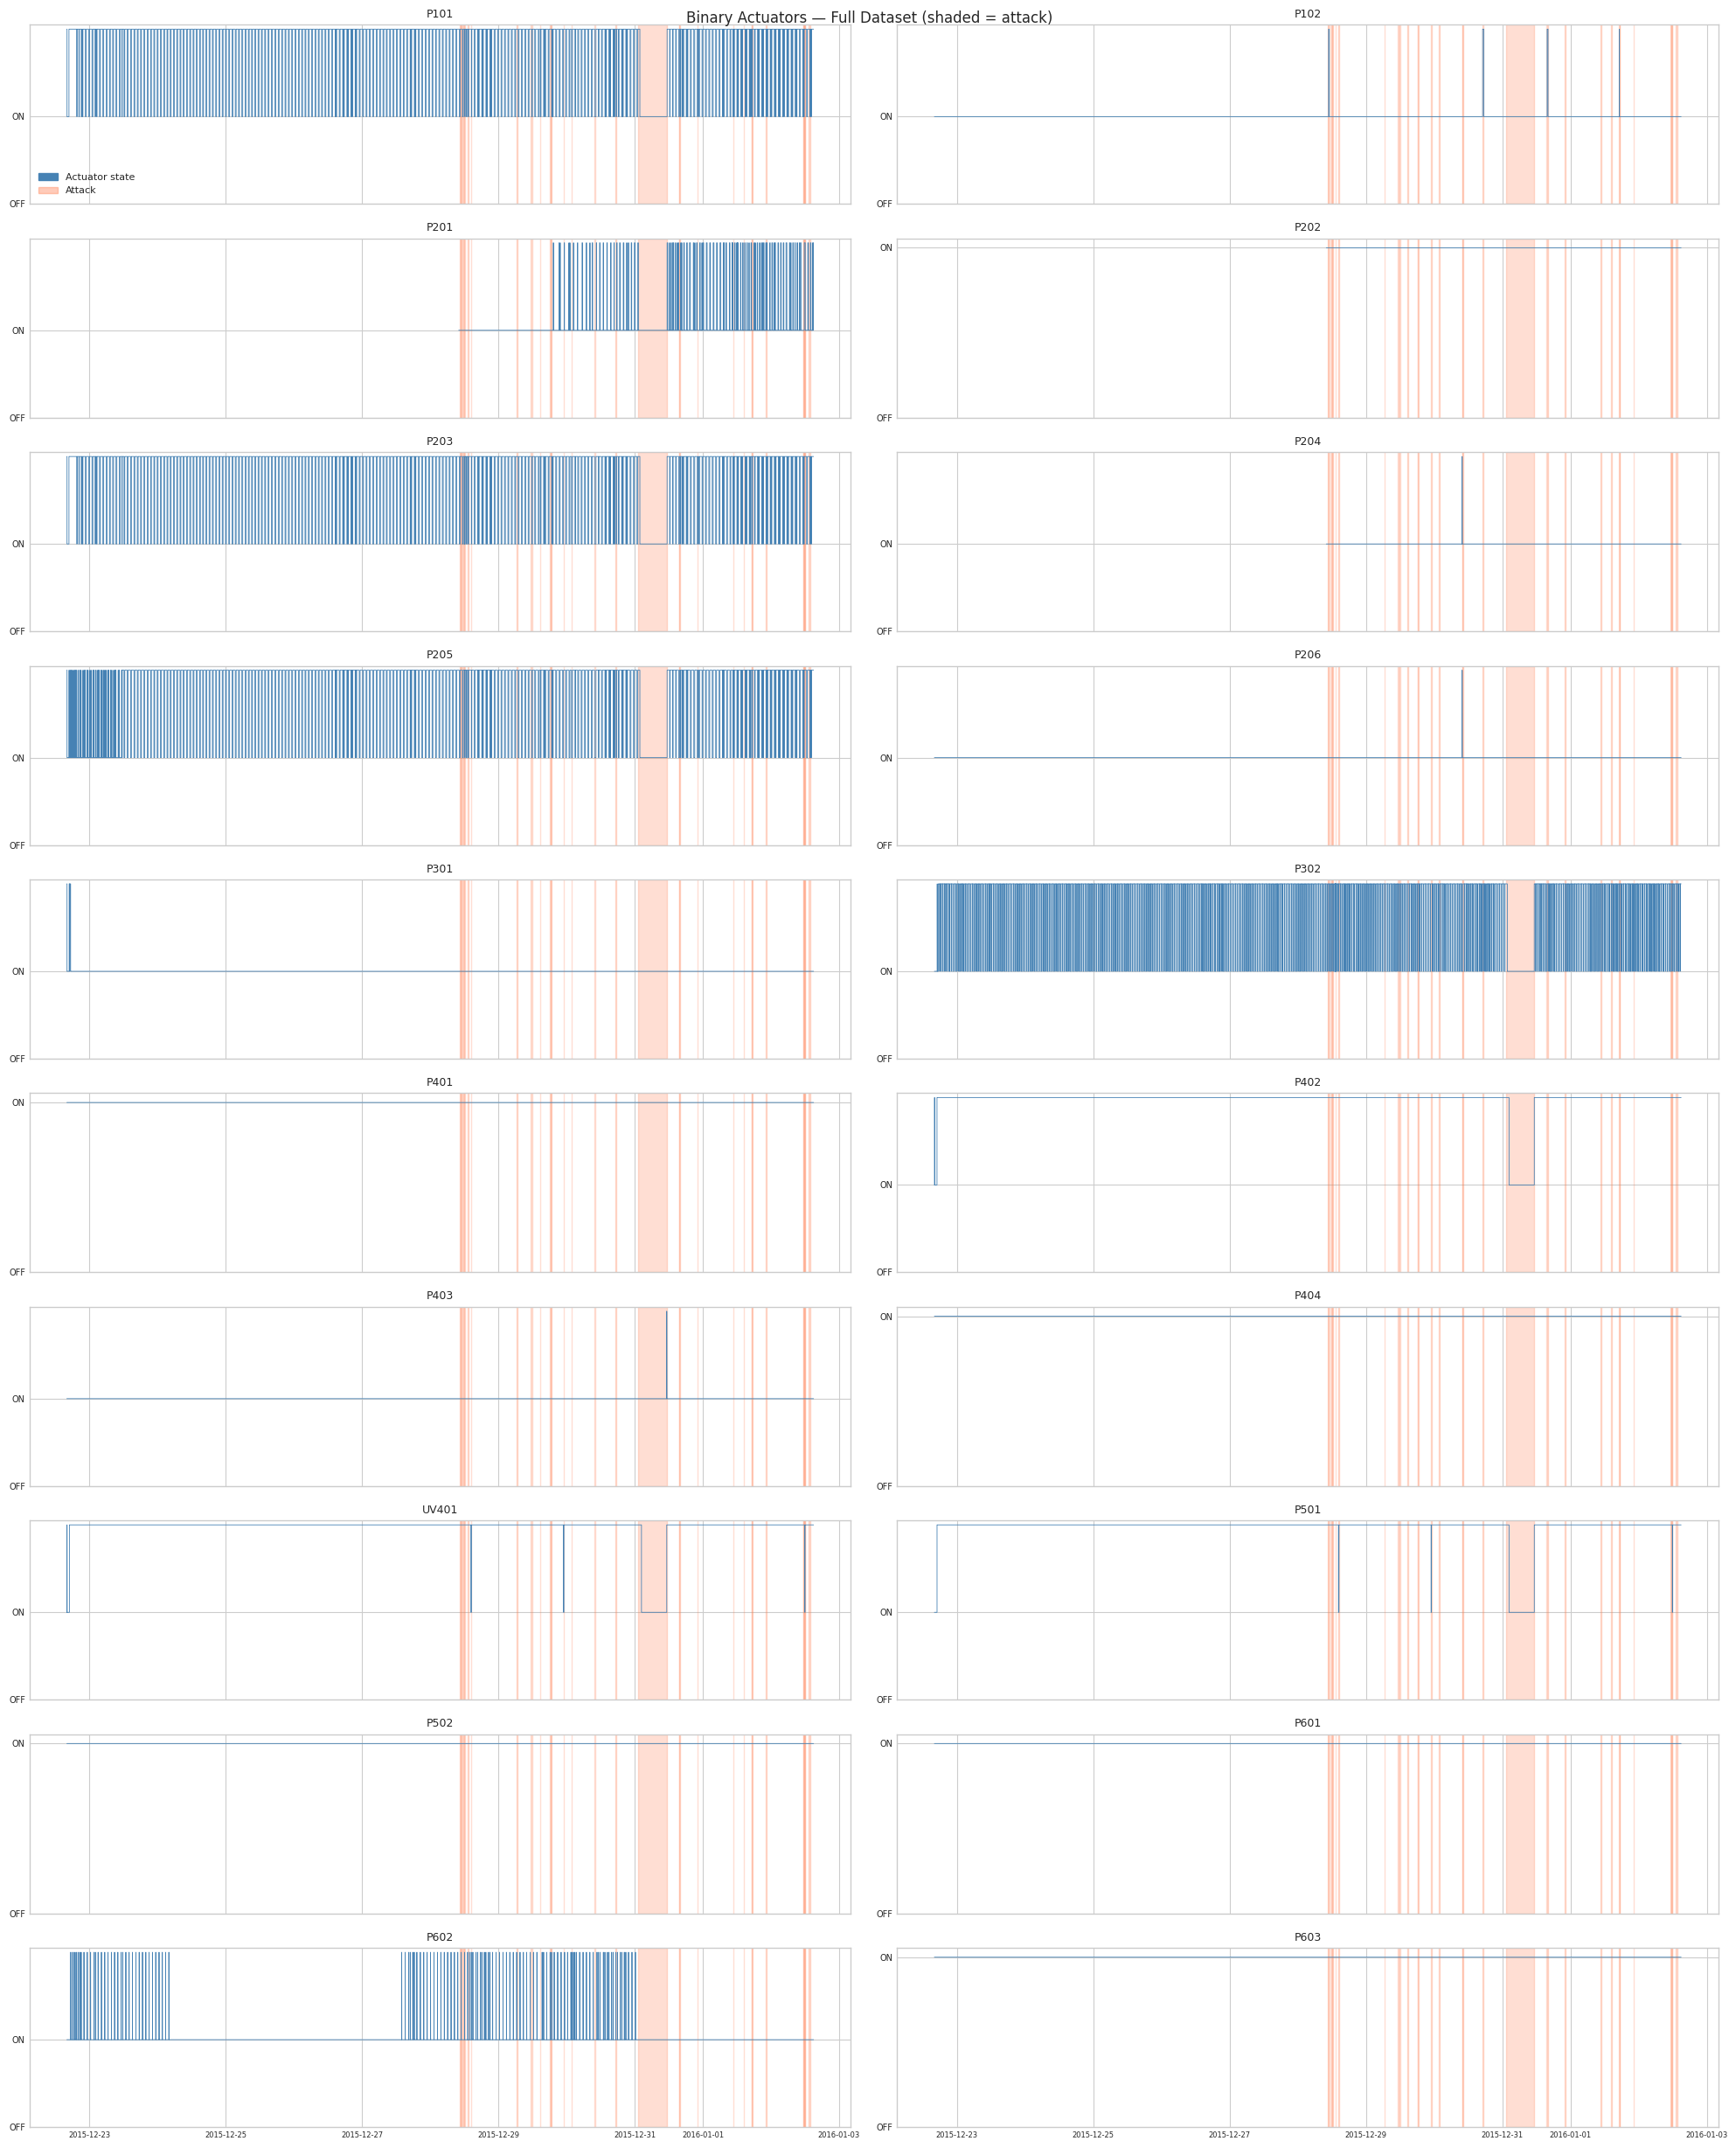

In [31]:
# ---- Time-series — binary actuators ----
# Downsample every 60s to preserve discrete steps
X_bin_ds = X[binary_cols].iloc[::60]

n_cols = 2
n_rows = int(np.ceil(len(binary_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 2.5), sharex=True)
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, binary_cols)):
    ax.plot(X_bin_ds.index, X_bin_ds[col], lw=0.6, color=CLR_NORMAL, drawstyle='steps-post')
    shade_attacks(ax, attack_episodes)
    ax.set_title(col, fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['OFF', 'ON'], fontsize=7)
    ax.tick_params(axis='x', labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(handles=[
    mpatches.Patch(color=CLR_NORMAL, label='Actuator state'),
    mpatches.Patch(color=CLR_ATTACK, alpha=0.4, label='Attack'),
], fontsize=8)

plt.suptitle('Binary Actuators — Full Dataset (shaded = attack)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'timeseries_binary_actuators.png', dpi=150, bbox_inches='tight')
plt.show()

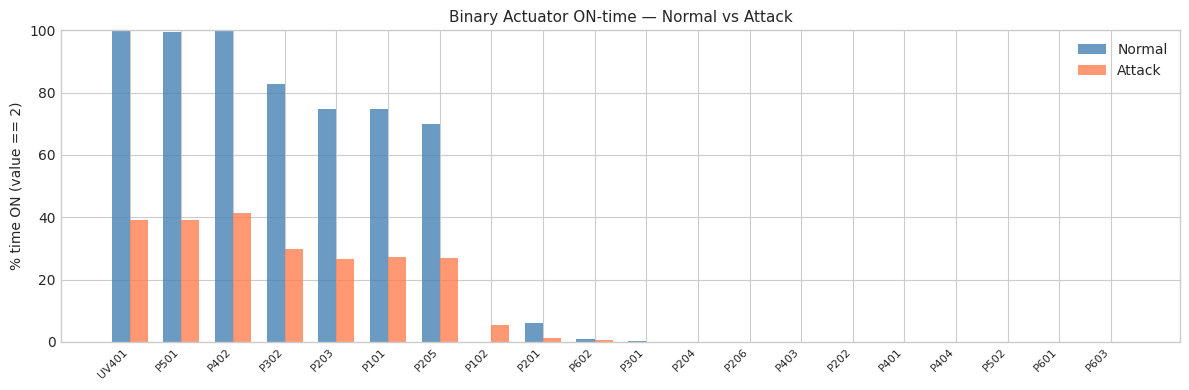

In [33]:
# ---- Binary actuator ON-time by class ----
# Values: 1 = OFF, 2 = ON  (will be remapped to 0/1 in feature engineering)
if binary_cols:
    binary_stats = pd.DataFrame({
        'normal_on_pct': [(X[c][y == 0] == 2).mean() * 100 for c in binary_cols],
        'attack_on_pct': [(X[c][y == 1] == 2).mean() * 100 for c in binary_cols],
    }, index=binary_cols)
    binary_stats['shift_pp'] = (binary_stats['attack_on_pct']
                                - binary_stats['normal_on_pct']).abs()
    binary_stats = binary_stats.sort_values('shift_pp', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(len(binary_stats))
    w = 0.35
    ax.bar(x - w/2, binary_stats['normal_on_pct'], w,
           label='Normal', color=CLR_NORMAL, alpha=0.8)
    ax.bar(x + w/2, binary_stats['attack_on_pct'], w,
           label='Attack', color=CLR_ATTACK, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(binary_stats.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('% time ON (value == 2)')
    ax.set_ylim(0, 100)
    ax.set_title('Binary Actuator ON-time — Normal vs Attack', fontsize=11)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / 'binary_actuators_by_class.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Correlation Analysis

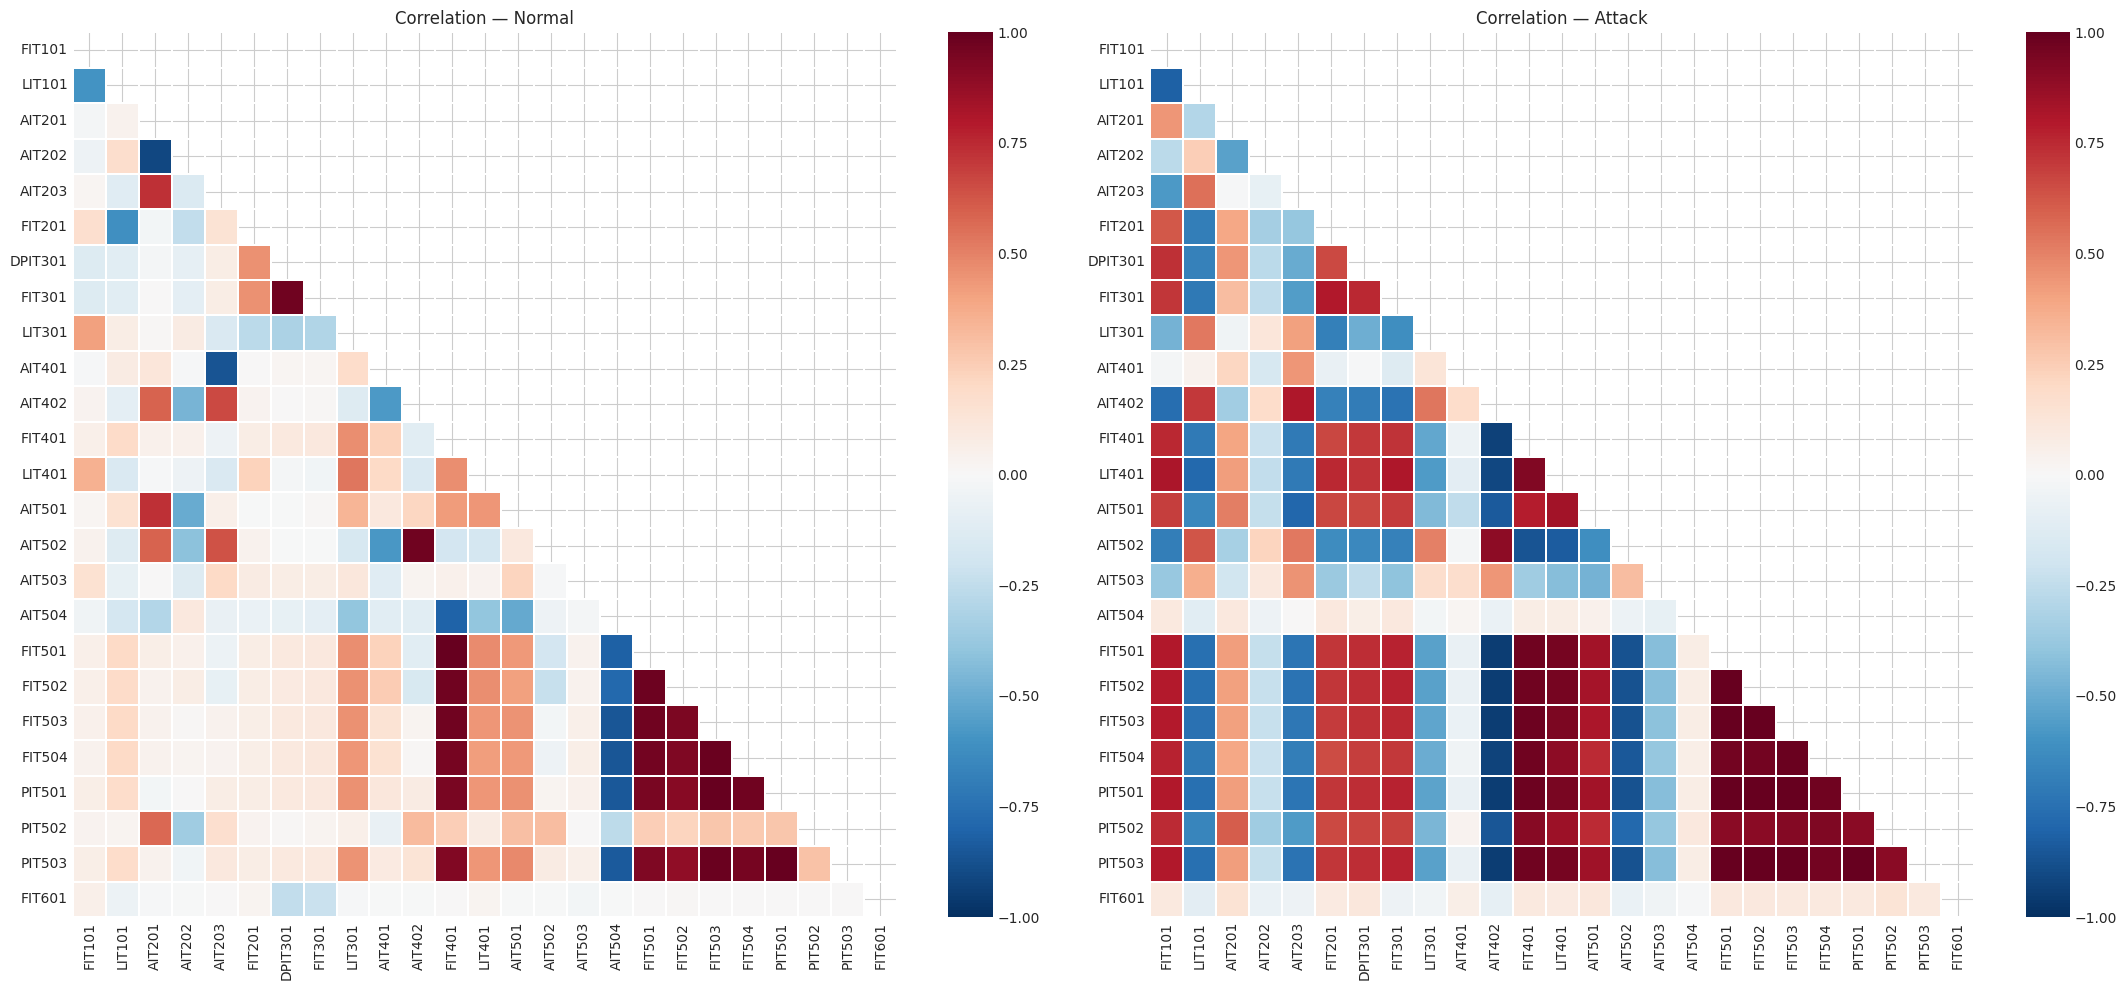

In [34]:
# ---- Correlation heatmaps: Normal vs Attack side-by-side ----
corr_normal = X[continuous_cols][y == 0].corr()
corr_attack = X[continuous_cols][y == 1].corr()
mask = np.triu(np.ones_like(corr_normal, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, corr, title in zip(axes,
                            [corr_normal, corr_attack],
                            ['Correlation — Normal', 'Correlation — Attack']):
    sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax)
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES / 'correlation_normal_vs_attack.png', dpi=150, bbox_inches='tight')
plt.show()

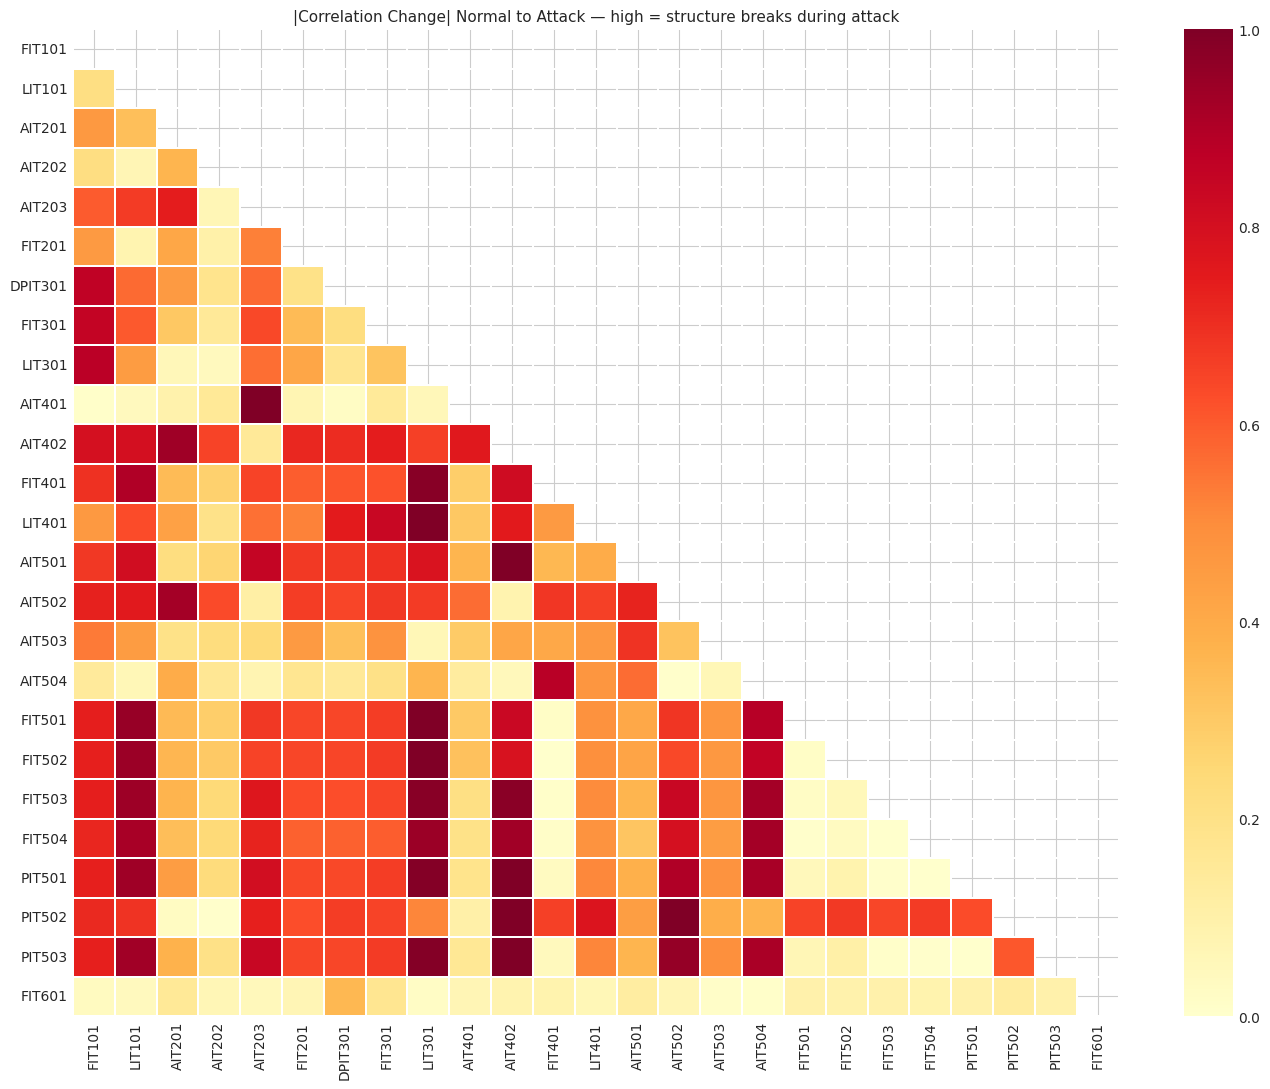

In [35]:
# ---- Correlation difference heatmap ----
# High values = sensor pairs whose relationship breaks during attacks
corr_diff = (corr_attack - corr_normal).abs()
corr_diff_masked = corr_diff.where(~mask)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_diff_masked, annot=False, cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.3, ax=ax)
ax.set_title('|Correlation Change| Normal to Attack — high = structure breaks during attack',
             fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'correlation_diff.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. EDA Summary & Preprocessing Checklist

In [36]:
# ---- Summary ----
summary = {
    'n_features_total':   len(FEATURE_COLS),
    'n_continuous':       len(continuous_cols),
    'n_mv_ordinal':       len(mv_cols),
    'n_binary_actuators': len(binary_cols),
    'n_total_rows':       len(X),
    'n_normal_rows':      int((y == 0).sum()),
    'n_attack_rows':      int((y == 1).sum()),
    'attack_pct':         round(y.mean() * 100, 2),
    'n_attack_episodes':  n_episodes,
    'imbalance_ratio':    round(imbalance_ratio, 1),
    'missing_values':     bool(X.isnull().sum().sum() > 0),
    'sampling_freq_s':    1,
}

print('=== EDA Summary ===')
for k, v in summary.items():
    print(f'  {k}: {v}')

print()
print('=== Preprocessing checklist for notebook 02 ===')
print('  [ ] Handle missing values (forward fill)')
print('  [ ] StandardScaler on continuous features')
print('  [ ] One-hot encode MV ordinal columns (0/1/2 -> 3 binary cols)')
print('  [ ] Keep binary actuators as-is')
print('  [ ] Engineer rolling features: mean_10s, std_10s, rate_of_change')
print('  [ ] Train/test split — respect time order (no shuffle)')
print('  [ ] Address class imbalance: class_weight or SMOTE')
print('  [ ] Save X_train, X_test, y_train, y_test as parquet')

=== EDA Summary ===
  n_features_total: 51
  n_continuous: 25
  n_mv_ordinal: 6
  n_binary_actuators: 20
  n_total_rows: 946728
  n_normal_rows: 892107
  n_attack_rows: 54621
  attack_pct: 5.77
  n_attack_episodes: 35
  imbalance_ratio: 16.3
  missing_values: True
  sampling_freq_s: 1

=== Preprocessing checklist for notebook 02 ===
  [ ] Handle missing values (forward fill)
  [ ] StandardScaler on continuous features
  [ ] One-hot encode MV ordinal columns (0/1/2 -> 3 binary cols)
  [ ] Keep binary actuators as-is
  [ ] Engineer rolling features: mean_10s, std_10s, rate_of_change
  [ ] Train/test split — respect time order (no shuffle)
  [ ] Address class imbalance: class_weight or SMOTE
  [ ] Save X_train, X_test, y_train, y_test as parquet


---
**Next:** `02_preprocessing.ipynb` — feature engineering, scaling, time-based train/test split